In [177]:
import torch
import requests
from pathlib import Path 
import torchvision
import pandas as pd
import numpy
from sklearn.model_selection import train_test_split
from torch import nn

In [178]:
#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Import make_moons data set, for consistency, the dataset should have 1000 samples and a random_state=42

In [179]:
#import data set and selrct samples
from sklearn.datasets import make_moons

n_samples = 1000
X, y = make_moons(n_samples,
                    noise = 0.03,
                    random_state =42)

X[:5], y[:5]

(array([[-0.00933187,  0.39098105],
        [ 0.95457387, -0.47375583],
        [ 0.9185256 , -0.42519648],
        [ 0.41276802, -0.37638459],
        [-0.84532016,  0.52879908]]),
 array([1, 1, 1, 1, 0], dtype=int64))

In [180]:
#make dataframe
moons = pd.DataFrame({"X1": X[:,0], 
                      "X2": X[:, 1],
                      "label" : y})
moons.head()

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


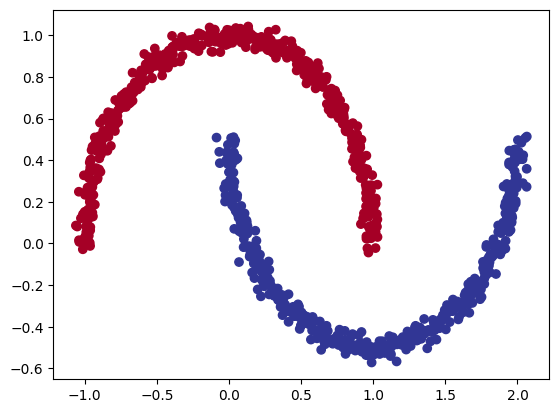

In [181]:
#visualize
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

In [182]:
X.shape, y.shape

((1000, 2), (1000,))

Turn the data into PyTorch tensors

In [183]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X[:5], y[:5]

(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

Split the data into training and test sets using train_test_split with 80% training and 20% testing

In [184]:
#X_train, y_train, X_test, y_test = train_test_split(X,
#                                                    y,
#                                                    test_size = 0.2,
#                                                    random_state = 42)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
#X_train = torch.from_numpy(X_train).type(torch.float)
#y_train = torch.from_numpy(y_train).type(torch.float)
#X_test = torch.from_numpy(X_test).type(torch.float)
#y_test = torch.from_numpy(y_test).type(torch.float)


In [185]:
# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 5)
        self.layer_2 = nn.Linear(in_features = 5, out_features = 5)
        self.layer_3 = nn.Linear(in_features = 5, out_features = 1)
#The use of the same variable x for each intermediate result is a common practice in PyTorch, it stores data which is travels between layers
    def forward(self,x):
        return self.layer_3(self.layer_1(x)) # layer_1 -> layer_2 -> layer_3 -> output

model_0 = MoonModelV0().to(device)
model_0

MoonModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=5, bias=True)
  (layer_3): Linear(in_features=5, out_features=1, bias=True)
)

Setup a binary classification compatible loss function and optimizer to use when training the model built before

In [186]:
loss_fn = loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

#accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_true)) * 100
  return acc

Create a training and testing loop to fit the model

In [187]:
y_train = y_train.view(-1)

In [188]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device 
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls
  
    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train) 
    loss = loss_fn(y_logits, # Using nn.BCE LogitsLoss works with raw logits
                   y_train) 
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred) 

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.no_grad():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.93515, Accuracy: 50.00% | Test loss: 0.88872, Test acc: 50.00%
Epoch: 10 | Loss: 0.71435, Accuracy: 50.00% | Test loss: 0.70139, Test acc: 50.00%
Epoch: 20 | Loss: 0.60500, Accuracy: 80.62% | Test loss: 0.60372, Test acc: 78.00%
Epoch: 30 | Loss: 0.52138, Accuracy: 81.88% | Test loss: 0.52812, Test acc: 78.00%
Epoch: 40 | Loss: 0.45455, Accuracy: 82.12% | Test loss: 0.46772, Test acc: 80.50%
Epoch: 50 | Loss: 0.40499, Accuracy: 82.38% | Test loss: 0.42253, Test acc: 81.00%
Epoch: 60 | Loss: 0.37028, Accuracy: 83.00% | Test loss: 0.39010, Test acc: 81.50%
Epoch: 70 | Loss: 0.34620, Accuracy: 83.25% | Test loss: 0.36675, Test acc: 81.50%
Epoch: 80 | Loss: 0.32907, Accuracy: 83.62% | Test loss: 0.34940, Test acc: 81.50%
Epoch: 90 | Loss: 0.31636, Accuracy: 84.00% | Test loss: 0.33592, Test acc: 82.00%


Helpers download

In [189]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


First visualization of results, as you can see it is something that we do not expect as final result, it looks like linear regression, while we need here something more curvy as separator:

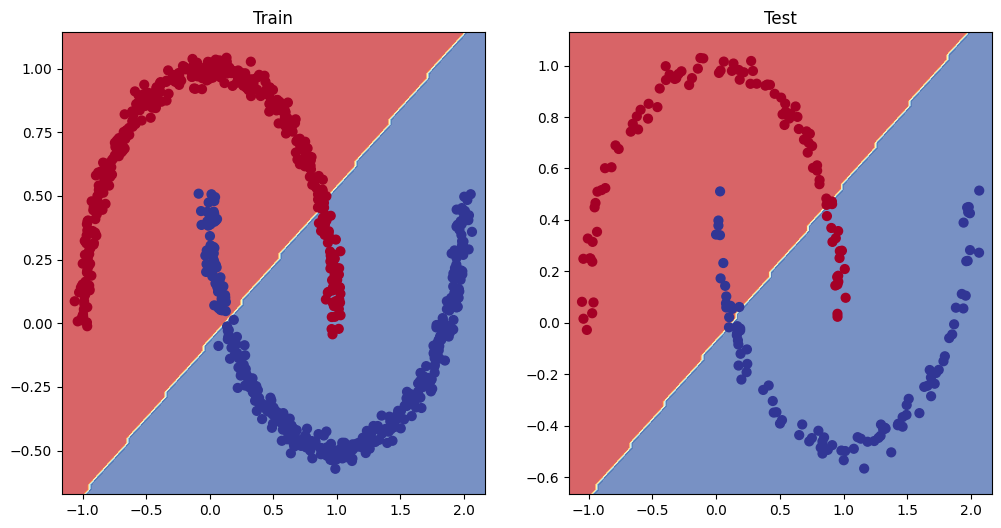

In [190]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

Improving model_0 (from a model perspective):

In [191]:
# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
#The use of the same variable x for each intermediate result is a common practice in PyTorch, it stores data which is travels between layers
    def forward(self,x):
        return self.layer_3(self.layer_2(self.layer_1(x))) # layer_1 -> layer_2 -> layer_3 -> output

model_1 = MoonModelV0().to(device)
model_1

MoonModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
#loss function and a small fix  of previous optimizer for new model:
loss_fn = loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.1)

In [192]:
torch.manual_seed(42)

epochs = 1000 # Train for longer

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> predicition probabilities -> prediction labels

    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                               y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 100 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 200 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 300 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 400 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 500 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 600 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 700 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 800 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%
Epoch: 900 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.71605, Test acc: 39.50%


Visualiziation of model_1, as you can see it looks better, but still not there, we need a curve, not straight line.

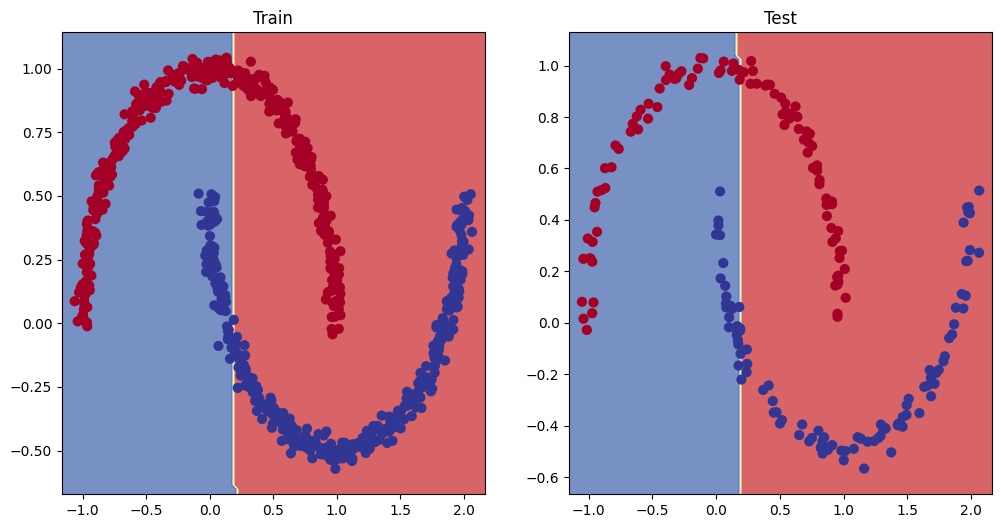

In [193]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

Further improvements: adding of relu() or sigmoid() to soften the curve

In [199]:
# Build model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = CircleModelV2().to(device)
print(model_2)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [200]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [201]:
# Fit the model
torch.manual_seed(42)
epochs = 1000

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    # 1. Forward pass
    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels
    
    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)
    
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_2(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calcuate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69537, Accuracy: 37.75% | Test Loss: 0.69457, Test Accuracy: 49.50%
Epoch: 100 | Loss: 0.38636, Accuracy: 81.88% | Test Loss: 0.40196, Test Accuracy: 77.00%
Epoch: 200 | Loss: 0.23664, Accuracy: 88.62% | Test Loss: 0.23758, Test Accuracy: 90.00%
Epoch: 300 | Loss: 0.19082, Accuracy: 91.38% | Test Loss: 0.18528, Test Accuracy: 92.50%
Epoch: 400 | Loss: 0.15147, Accuracy: 93.75% | Test Loss: 0.14452, Test Accuracy: 94.00%
Epoch: 500 | Loss: 0.10692, Accuracy: 95.62% | Test Loss: 0.09974, Test Accuracy: 97.50%
Epoch: 600 | Loss: 0.06902, Accuracy: 98.50% | Test Loss: 0.06298, Test Accuracy: 99.00%
Epoch: 700 | Loss: 0.04417, Accuracy: 99.75% | Test Loss: 0.03936, Test Accuracy: 99.50%
Epoch: 800 | Loss: 0.03007, Accuracy: 100.00% | Test Loss: 0.02625, Test Accuracy: 100.00%
Epoch: 900 | Loss: 0.02188, Accuracy: 100.00% | Test Loss: 0.01887, Test Accuracy: 100.00%


In [202]:
# Make predictions
model_2.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_2(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

As you can see, no the data classified (separated) perfectly

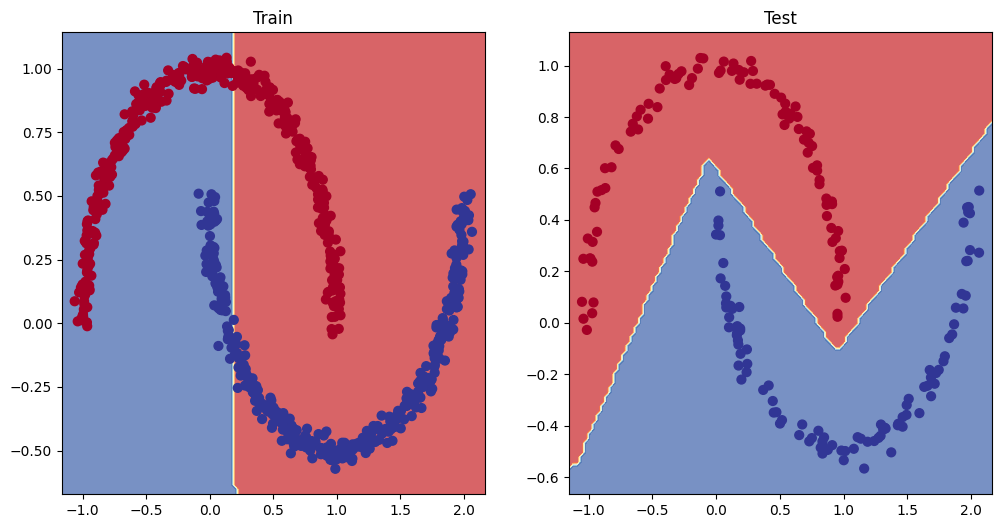

In [203]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity